In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120})

DATA_DIR = Path("../data")
if not DATA_DIR.exists():
    DATA_DIR = Path("Durga/Lab/MLDL/data")

pd.set_option("display.max_columns", 120)

In [2]:
from sklearn.impute import SimpleImputer
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

df = pd.read_csv(DATA_DIR / "diabetes_knn.csv")
display(df.head())
display(df["Outcome"].value_counts().rename_axis("Outcome").reset_index(name="count"))

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


,Outcome,count
0,0,500
1,1,268


In [3]:
zero_as_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
clean = df.copy()
clean[zero_as_missing] = clean[zero_as_missing].replace(0, np.nan)

X = clean.drop(columns=["Outcome"])
y = clean["Outcome"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

results = []
for k in range(1, 26, 2):
    model = Pipeline(
        steps=[
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
            ("knn", KNeighborsClassifier(n_neighbors=k)),
        ]
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results.append({"k": k, "accuracy": accuracy_score(y_test, pred), "f1": f1_score(y_test, pred)})

results_df = pd.DataFrame(results)
display(results_df)

best_k = int(results_df.sort_values(["f1", "accuracy"], ascending=False).iloc[0]["k"])
print("Selected k:", best_k)

,k,accuracy,f1
0,1,0.708333,0.548387
1,3,0.713542,0.580153
2,5,0.734375,0.592000
3,7,0.723958,0.569106
4,9,0.729167,0.593750
5,11,0.734375,0.585366
6,13,0.729167,0.580645
7,15,0.723958,0.569106
8,17,0.723958,0.561983
9,19,0.739583,0.583333


Selected k: 25


              precision    recall  f1-score   support

           0       0.78      0.86      0.81       125
           1       0.67      0.54      0.60        67

    accuracy                           0.74       192
   macro avg       0.72      0.70      0.70       192
weighted avg       0.74      0.74      0.74       192



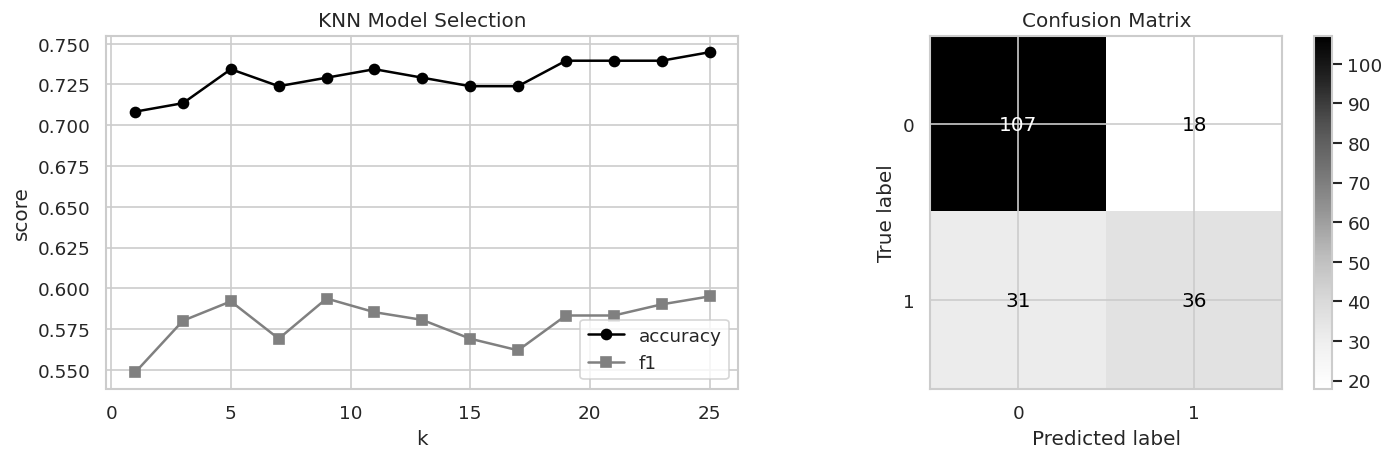

In [4]:
best_model = Pipeline(
    steps=[
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=best_k)),
    ]
)
best_model.fit(X_train, y_train)
pred = best_model.predict(X_test)
print(classification_report(y_test, pred))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(results_df["k"], results_df["accuracy"], marker="o", label="accuracy", color="black")
axes[0].plot(results_df["k"], results_df["f1"], marker="s", label="f1", color="gray")
axes[0].set_xlabel("k")
axes[0].set_ylabel("score")
axes[0].set_title("KNN Model Selection")
axes[0].legend()
ConfusionMatrixDisplay.from_predictions(y_test, pred, ax=axes[1], cmap="Greys")
axes[1].set_title("Confusion Matrix")
plt.tight_layout()
plt.show()